In [1]:
import torch
import torch.nn as nn 
import numpy as np
import matplotlib.pyplot as plt 
import numpy as np 
import time 
import os
import sys
import pandas as pd 

In [2]:
from scipy.optimize import minimize
import numpy as np

## Problem 
(The general setup)
 	The cost functional is given by        
$$
\begin{equation}
 		J[u]=\frac{1}{2} \int_0^T \sum^d_{i=1}\mathbb{E}[(x^i-x^{i,*})^2 ]dt +\frac{1}{2} \int_0^T \sum^d_{i=1} u^{i,2}(t) dt + \frac{1}{2} \sum^{d-1}_{i=1} (x_T^i)^2, \ K = U
\end{equation}
$$
 	The forward process is given by 
 	\begin{equation}
 		d x^i(t) = u^i(t) -r^i(t) dt + \sigma u^i(t) dW_t \  \  	
    \end{equation}
 	And one needs to find $u \in K$ such that 
 	$$
 	J(u^*)=\min_{u\in K} J(u)
 	$$
 	where $u^{i,*}$ is the optimal control of this problem. 


For simplicity, we consider only the two dimensional case

We pick the dimension to be 8, and we pick the function $r^i, x^{i,*}$ to be the following, and $u^i_t$ can be found accordingly. 
\begin{align}
	& r^1_t := \frac{-t^2/2}{\beta_t}, \ x^{1,*}=t+(\frac{T^2}{2 \sigma^2} - \frac{X^1_T}{\sigma^2}  ) \alpha_t , \  u^1_t= \frac{-t^2/2+T^2/2-X_T^1}{\beta_t} \nonumber \\ 
	&r^2_t :=\frac{-\sin(t)}{\beta_t}, \ x^{2,*}=\cos(t) +(\frac{\sin(T)}{\sigma^2}- \frac{X^2_T}{\sigma^2} )\alpha_t , \ u^2_t :=\frac{-\sin(t)+\sin(T)-X^2_T}{\beta_t} 
\end{align}

where $$\alpha_t=\ln\frac{(1+\sigma^2)+\sigma^2 T}{(\sigma^2+1)+\sigma^2(T-t)} \ , \ \beta_t=(1+\sigma^2)+\sigma^2(T-t) $$
and with $D=\ln(1+\frac{\sigma^2 T}{1+\sigma^2} )/ \big(\sigma^2+\ln(1+\frac{\sigma^2 T}{1+\sigma^2} )  \big) $
\begin{align}
	&X^1_T=\frac{T^2}{2}D, \ X^2_T=\sin(T)D
\end{align}

Equations:
$$
 	\begin{equation}
 		d x^i(t) = u^i(t) -r^i(t) dt + \sigma u^i(t) dW_t \  \  	
    \end{equation}
$$
 	And one needs to find $u \in K$ such that 


In [3]:
torch.set_default_dtype(torch.float32)

In [4]:
class SDE1(object):
    def __init__(self, T=1.0, σ=0.5,N=20,batch_size=16): 
        self.T=T
        self.sigma=σ
        self.dim=2
        self.N=N; 
        self.dt=self.T/self.N
        self.batch_size=batch_size

    def drift(self,t,xvec, utensor, return_vals='b'): 
        """
        In the case where u is only deterministic, u is only of dimenson 2. 
        
        uvec is in the batch mode
        
        """
        
        def beta(t,T,σ): 
            op=(1.0+σ**2)+σ**2*(T-t)
            return op

        beta_t=beta(t,self.T, self.sigma)
        r1=-t**2/2.0/beta_t
        r2=-np.sin(t)/beta_t
        rvec=np.array([r1,r2])
        
        b=utensor-rvec
         
        return b,rvec
    
    def diffusion(self,utensor):
        """"
        uvec is in the batch mode
        
        """
        sig = self.sigma*utensor
       # np.multiply(a,b)
        return sig

    def generate_SDE(self,Utensor):
        """
        Utensor is not a list
        """
        x0=np.zeros((self.batch_size, self.dim))
        xlist=list()
        wlist=list()
        tvec=np.arange(0,self.T,self.T/self.N) #length N
        
        xlist.append(x0)
        rvec_list=list()
        for i in range(0,self.N):
            dw=np.sqrt(self.dt)*np.random.randn(*x0.shape)
            b_out, r_out=self.drift(tvec[i],xlist[-1], Utensor[i])
            xtemp=xlist[-1]+ b_out *self.dt+ self.diffusion(Utensor[i])*dw
            xlist.append(xtemp)
            wlist.append(dw)
            rvec_list.append(r_out)

        self.rlist=rvec_list

        return xlist, wlist

    def init_utensor1(self):
        u0=np.zeros([self.dim])
        Uvec=list()
        for i in range(self.N):
            Uvec.append(np.zeros([self.dim]))
        return np.array(Uvec)

    def Uvec(self):
        tvec=np.arange(0,self.T,self.T/self.N) #length N
        arg=1.0+(self.sigma**2 * self.T)/(1.0+self.sigma**2)
        D=np.log(arg)/(self.sigma**2+np.log(arg))
        
        x1T=self.T**2/2.0*D
        x2T=np.sin(self.T)*D

        def beta(t,T,σ): 
            op=(1.0+σ**2)+σ**2*(T-t)
            return op

        
        u1vec=np.zeros(tvec.shape)
        u2vec=np.zeros(tvec.shape)
        
        for i in range(len(tvec)):
            t=tvec[i]
            beta_t=beta(t,self.T, self.sigma)
            u1=(-t**2/2.0+self.T**2/2.0-x1T)/beta_t
            u2=(-np.sin(t)+np.sin(self.T)-x2T)/beta_t
            u1vec[i]=u1
            u2vec[i]=u2
        return u1vec, u2vec


In [5]:
class YZSampler(object):
    def __init__(self,T,σ=0.5,N=20,batch_size=16):
        self.T=T; 
        self.N=N; 
        self.dt=self.T/self.N
        self.sigma=σ
        self.batch_size=batch_size

        self.arg=1.0+self.sigma**2 * self.T/(1.0+self.sigma**2)
        self.D=np.log(self.arg)/(self.sigma**2+np.log(self.arg)) 

    def g_x(self,xtensor):
        return xtensor

    def x_star(self,t,D,alpha_t):
        x1T=self.T**2/2.0*D
        x1_star=t+(self.T**2/(2.0*self.sigma**2) - x1T/self.sigma**2)*alpha_t

        x2T=np.sin(self.T)*D
        x2_star=np.cos(t)+(np.sin(self.T)/self.sigma**2 - x2T/self.sigma**2)*alpha_t
        return np.array([x1_star, x2_star])

    def f_x(self,t,xtensor):
 
        alpha_t=np.log( ((1.0+self.sigma**2)+self.sigma**2*self.T)/((1.0+self.sigma**2)+self.sigma**2*(self.T-t)) )  
            
        output=xtensor-self.x_star(t,self.D,alpha_t)
        return output

    def x_starVec(self, tVec): 
        xstar_list=list()
        for t in tVec: 
            alpha_t=np.log( ((1.0+self.sigma**2)+self.sigma**2*self.T)/((1.0+self.sigma**2)+self.sigma**2*(self.T-t)) )
            xstar_temp=self.x_star(t,self.D,alpha_t)
            xstar_list.append(xstar_temp)
        return np.array(xstar_list)

    def b_u(self,t,utensor, xtensor): 
        res=np.ones(utensor.shape)
        return res

    def sigma_u(self,t,utensor,xtensor): 
        res=self.sigma
        return res 

    def f_u(self,t,utensor,xtensor):
        res=utensor
        return res 
   

    def YZ(self,xlist,wlist):
        YT=self.g_x(xlist[-1])

        Ylist=list()
        Zlist=list()
        tvec=np.arange(0,self.T,self.T/self.N)
        Ylist.append(YT)
        
        for i in range(self.N-1,-1,-1): 
            xtensor=xlist[i]
            t=tvec[i]
            dw=wlist[i]

            ## Both b_x and sigma_x are 0
            Zt= Ylist[-1]*dw/self.dt
            Yt= Ylist[-1]+self.dt*(self.f_x(t,xtensor))
            

            Ylist.append(Yt)
            Zlist.append(Zt)

        return Ylist[::-1], Zlist[::-1]


    def gradU1(self,Xlist,Ylist,Zlist,Utensor):
        """
        Utensor is a collection of all the control parameters but it is a tensor array
        """
        tvec=np.arange(0,self.T,self.T/self.N)
        GUlist=list()
        for i in range(self.N):
            xtensor, ytensor,ztensor,utensor=Xlist[i],Ylist[i],Zlist[i],Utensor[i]
    
            gradu=np.mean(ytensor,axis=0)+np.mean(self.sigma*ztensor,axis=0)+utensor
    
            GUlist.append(gradu)
    
        return np.array(GUlist)

    def maxHam(self,Xlist,Ylist,Zlist,Utensor):
        """
        Directly find the control that maximizes the batch Hamiltonian. 
        """
        tvec=np.arange(0,self.T,self.T/self.N)
        GUlist=list()
        for i in range(self.N):
            xtensor, ytensor,ztensor,utensor=Xlist[i],Ylist[i],Zlist[i],Utensor[i]
            temp=-ytensor-self.sigma*ztensor
            GUlist.append( np.mean(temp, axis=0) )
            
        return np.array(GUlist)

    def enhanced_ham(self,utensor,xtensor1,xtensor,ytensor,ztensor, wtensor,rvec, rho):
        ham=np.sum((utensor-rvec)*ytensor+self.sigma*utensor*ztensor,axis=1)+np.sum(0.5*(utensor)*utensor)
        ham_mean=np.mean(ham)

        addon=rho*np.sum((xtensor1-(xtensor+(utensor-rvec)*self.dt+self.sigma*utensor*wtensor))**2, axis=1) 
        addon_mean=np.mean(addon,axis=0)

        return addon_mean+ham_mean

    def maxHam_enhanced(self,Xlist,Ylist,Zlist,Utensor,Wlist,rlist,rho):
        """
        Directly find the control that maximizes the batch Hamiltonian. 
        We also further added extra terms to potentially increase the stability of the result.  
        """
        
        tvec=np.arange(0,self.T,self.T/self.N)
        GUlist=list()
            
        for i in range(self.N):
            xtensor1,xtensor,ytensor,ztensor,utensor, rvec,wtensor,=Xlist[i+1],Xlist[i],Ylist[i],Zlist[i],Utensor[i],Wlist[i],rlist[i]

            #res=self.enhanced_ham(utensor,xtensor1,xtensor,ytensor,ztensor, wtensor,rvec, 0.1)
            utensor0=minimize(self.enhanced_ham, x0=np.zeros(2), args=(xtensor1,xtensor,ytensor,ztensor, wtensor,rvec, rho))
        
            GUlist.append(utensor0.x)
            
        return np.array(GUlist)


# The maxHam enhanced

In [6]:
N=20
K=3*N**2
bsize=32
sigma_in=0.5
T=1.0
YZs=YZSampler(T=T,σ=sigma_in,N=N,batch_size=bsize)
tvec=np.arange(0,T,T/N)
xstarList=YZs.x_starVec(tvec)


def Loss_J(uvec, T, sigma_in, N, batch_size=1024): 
    sde_l=SDE1(T=T, σ=sigma_in, N=N,batch_size=batch_size); 
    dt=T/N
    X_tensor, _ = sde_l.generate_SDE(uvec)
    X_tensor=np.array(X_tensor)
    tvec=np.arange(0,T,T/N)

    YZs=YZSampler(T=T,σ=sigma_in,N=N,batch_size=bsize)
    xstarList=YZs.x_starVec(tvec)
    
    X_rieman, XT =X_tensor[:-1,:,:], X_tensor[-1,:,:]

    runsum=0.0
    for i in range(len(tvec)):      
        xrun=np.sum(np.mean( (X_rieman[i,:,:]-xstarList[i,:])**2, axis=0)); 
        urun=np.sum((uvec[i,:])**2) 
        runsum=runsum+0.5*(xrun+urun)*dt

    runsum=runsum+ np.sum(np.mean( (XT)**2, axis=0))*0.5
    return runsum
    

In [7]:
### 
#### This is a bit slow
mem=0.995

K=500
N=int(1.0/(mem**K))
#K=3*N**2
bsize=N^2

sigma_in=0.5
T=0.5
sde=SDE1(T=T, σ=sigma_in, N=N,batch_size=bsize)
YZs=YZSampler(T=T,σ=sigma_in,N=N,batch_size=bsize)

v1,v2=sde.Uvec()
#temp_u=Utensor0
#Utensor0=temp_u
Utensor0=sde.init_utensor1()
for k in range(1,K+1): 
    xlist1,wlist1=sde.generate_SDE(Utensor0)
    rlist1=sde.rlist
    
    ylist1, zlist1=YZs.YZ(xlist1,wlist1)
    maxU_loc=YZs.maxHam_enhanced(xlist1,ylist1,zlist1,Utensor0,wlist1,rlist1,0.1)
    #print(maxU_loc)

    #Utensor0=Utensor0+1.0/k*gradu
    Utensor0=mem*Utensor0+(1.0-mem)*maxU_loc

loss_res=Loss_J(Utensor0, T, sigma_in, N, batch_size=1024)
loss_res

0.266554429228173

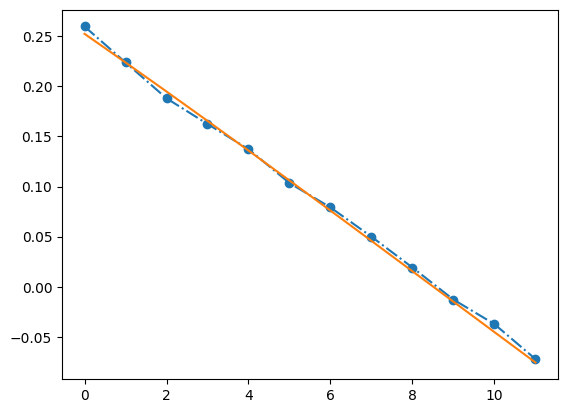

In [8]:
plt.plot(Utensor0[:,1],linestyle='-.',marker='o')
plt.plot(v2)

# The usual SGD

In [20]:
### 
N=40
K=N**2#int(0.5*N**3) #3*N**2 #N**2
bsize=N
sigma_in=0.5
sde=SDE1(T=1.0, σ=sigma_in, N=N,batch_size=bsize)
YZs=YZSampler(T=1.0,σ=sigma_in,N=N,batch_size=bsize)

v1,v2=sde.Uvec()

start_time = time.time()
Utensor0=sde.init_utensor1()
for k in range(1,K+1): 
    xlist1,wlist1=sde.generate_SDE(Utensor0)
    ylist1, zlist1=YZs.YZ(xlist1,wlist1)
    gradu=YZs.gradU1(xlist1,ylist1, zlist1,Utensor0)

    Utensor0=Utensor0-1.0/k*gradu
end_time=time.time()

end_time-start_time
#loss_res=Loss_J(Utensor0, T, sigma_in, N, batch_size=1024)
#loss_res

#err_list=[]
#for epoch in range(50): 
#    err_list.append(avg_run_sgd(N=40))

#np.mean(np.array(err_list)) 

1.0217499732971191

In [21]:
np.sqrt(np.sum((Utensor0[:,1]-v2)**2)*T/N+np.sum((Utensor0[:,0]-v1)**2)*T/N)

0.004677957887336814

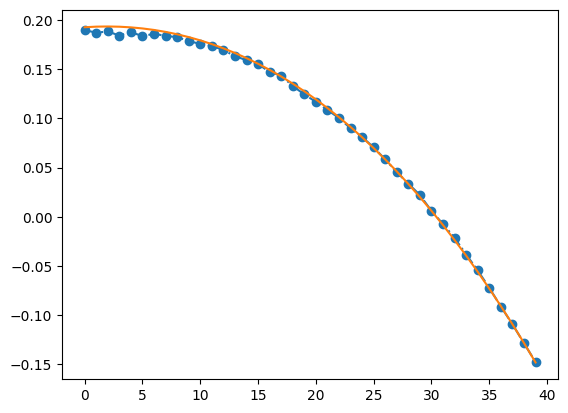

In [22]:
plt.plot(Utensor0[:,0],linestyle='-.',marker='o')
plt.plot(v1)

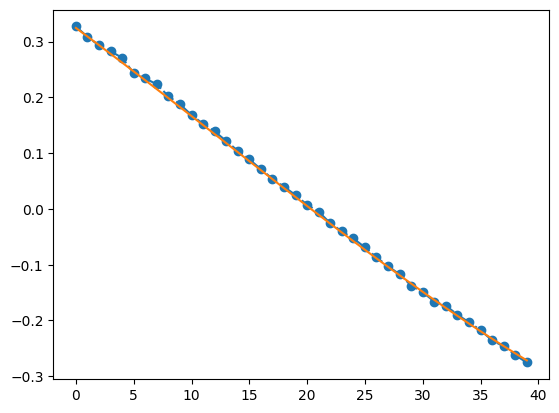

In [23]:
plt.plot(Utensor0[:,1],linestyle='-.',marker='o')
plt.plot(v2)

## Batch decay test

## Using true maximization

In [16]:
### 
K=710
mem=0.995
N=40 #int(1.0/(mem**K))  #20           #100*N**2 #N**2
bsize=N**2 #32  ## try constant multiple of N
sigma_in=0.5
T=1.0

sde=SDE1(T=T, σ=sigma_in, N=N,batch_size=bsize)
YZs=YZSampler(T=T,σ=sigma_in,N=N,batch_size=bsize)

v1,v2=sde.Uvec()

#temp_u=Utensor0
#Utensor0=temp_u
time_start=time.time()
Utensor0=sde.init_utensor1()

for k in range(1,K+1): 
    xlist1,wlist1=sde.generate_SDE(Utensor0)
    ylist1, zlist1=YZs.YZ(xlist1,wlist1)
    maxU_loc=YZs.maxHam(xlist1,ylist1, zlist1,Utensor0)

    Utensor0=mem*Utensor0+(1.0-mem)*maxU_loc
    
time_end=time.time()
N, time_end-time_start

(40, 1.9391639232635498)

0.0037120696871630744

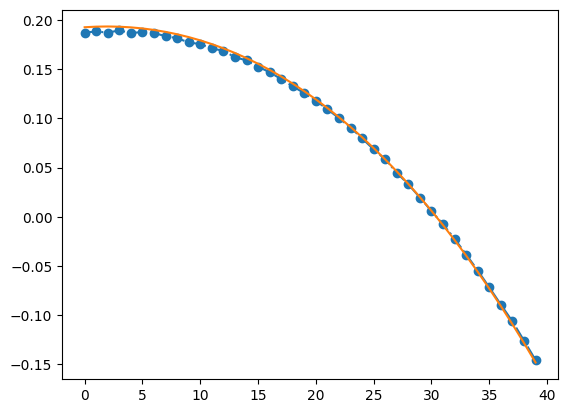

In [17]:
plt.plot(Utensor0[:,0],linestyle='-.',marker='o')
plt.plot(v1)
np.sqrt(np.sum((Utensor0[:,1]-v2)**2)*T/N+np.sum((Utensor0[:,0]-v1)**2)*T/N)

0.0037120696871630744

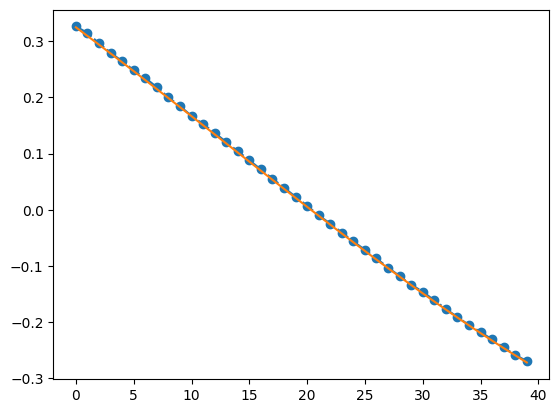

In [18]:
plt.plot(Utensor0[:,1],linestyle='-.',marker='o')
plt.plot(v2)
np.sqrt(np.sum((Utensor0[:,1]-v2)**2)*T/N+np.sum((Utensor0[:,0]-v1)**2)*T/N)

In [148]:
#df_controlled_contraction=pd.DataFrame(Utensor0) 
#df_controlled_contraction.to_csv('assets_figures/controlled_contraction.csv', index=False)
#df_controlled_exact=pd.DataFrame(np.vstack([v1,v2]).T)
#df_controlled_exact.to_csv('assets_figures/controlled_exact_contract.csv', index=False)